In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from deap import base, creator, tools, algorithms

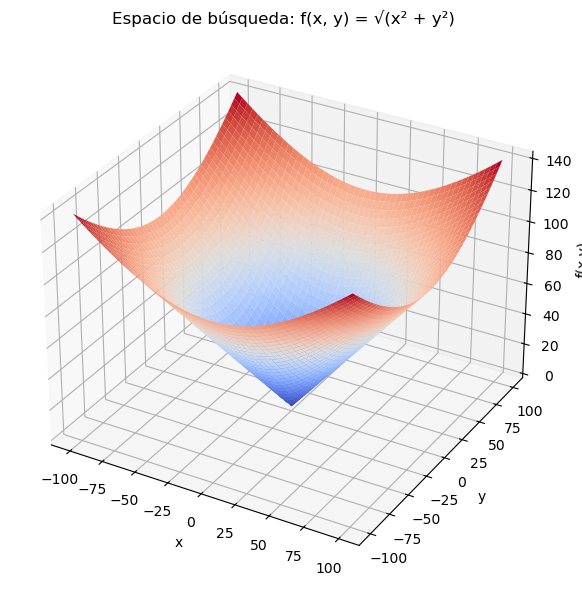

In [3]:
def graficar_funcion():
    def funcion_prueba(x):
        return np.sqrt(x[0] ** 2 + x[1] ** 2)
 
    x = np.linspace(-100, 100, 1000)
    y = np.linspace(-100, 100, 1000)
    x_ax, y_ax = np.meshgrid(x, y)
    vals = np.c_[x_ax.ravel(), y_ax.ravel()]
    fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))
 
    figure_3d = plt.figure(figsize=(8, 6))
    ax = figure_3d.add_subplot(111, projection="3d")
    ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")
    plt.title("Espacio de búsqueda: f(x, y) = √(x² + y²)")
    plt.tight_layout()
    plt.show()
 
graficar_funcion()

In [4]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0] ** 2 + x[1] ** 2)
    return res,

In [5]:
def plot_evolucion(log, titulo="Convergencia del Algoritmo Genético"):
    gen      = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave  = np.array(log.select("avg"), dtype=float)
 
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(gen, fit_mins, "b",   label="Min")
    ax1.plot(gen, fit_maxs, "r",   label="Max")
    ax1.plot(gen, fit_ave,  "--k", label="Avg")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs,
                     where=where_mask, facecolor="g", alpha=0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(loc="lower center")
    ax1.set_title(titulo)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [6]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
 
def crear_toolbox():
    toolbox = base.Toolbox()
    # Generación de genes dentro del dominio [-100, 100]
    toolbox.register("attr_uniform", random.uniform, -100, 100)
    # Creación del individuo (2 variables: x, y)
    toolbox.register("individual", tools.initRepeat,
                     creator.Individual, toolbox.attr_uniform, 2)
    # Creación de la población
    toolbox.register("population", tools.initRepeat,
                     list, toolbox.individual)
    # Operadores genéticos
    toolbox.register("evaluate", funcion_objetivo)
    toolbox.register("mate",    tools.cxOnePoint)
    toolbox.register("mutate",  tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
    toolbox.register("select",  tools.selTournament, tournsize=3)
    return toolbox


In [7]:
def ejecutar_ag(n_individuos, n_generaciones=20, cxpb=0.5, mutpb=0.2, seed=42):
    random.seed(seed)
    toolbox = crear_toolbox()
    pop     = toolbox.population(n=n_individuos)
    hof     = tools.HallOfFame(1)
 
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
 
    _, log = algorithms.eaSimple(pop, toolbox,
                                 cxpb=cxpb, mutpb=mutpb,
                                 ngen=n_generaciones,
                                 stats=stats, halloffame=hof,
                                 verbose=True)
    return hof, log


  Población: n = 10
gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779


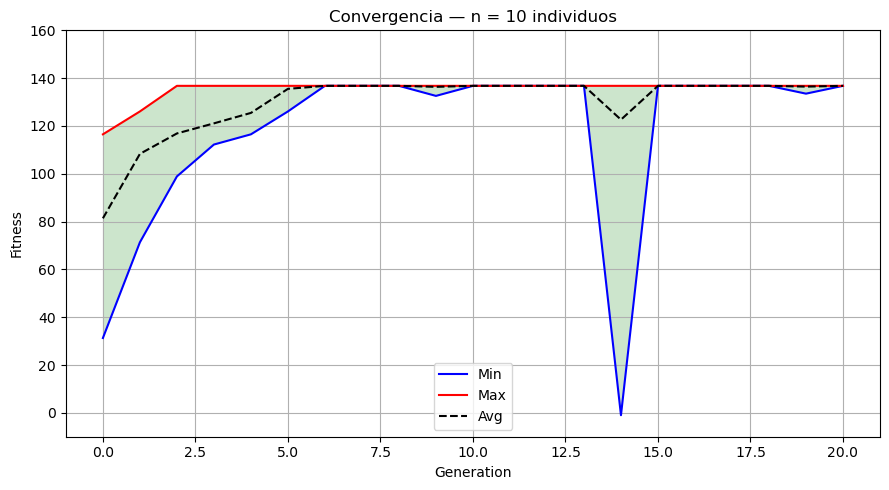


  Población: n = 30
gen	nevals	avg    	std   	min    	max    
0  	30    	77.9162	24.544	26.4289	116.497
1  	15    	98.1576	15.6516	58.7221	123.194
2  	18    	108.641	17.0172	47.071 	131.857
3  	24    	122.041	7.64215	99.9797	134.549
4  	19    	128.584	3.92487	122.005	134.549
5  	11    	132.005	2.13284	125.135	134.549
6  	22    	133.419	1.60997	131.169	136.779
7  	20    	130.449	24.4622	-1     	136.779
8  	17    	136.143	1.12918	133.455	137.464
9  	16    	136.686	0.662231	134.132	137.486
10 	14    	137.114	0.611792	136.779	139.908
11 	15    	137.235	1.30432 	131.674	139.908
12 	23    	137.979	0.981347	137.464	140.041
13 	21    	133.762	25.0534 	-1     	140.101
14 	17    	138.776	1.53284 	133.594	140.101
15 	15    	130.265	35.0922 	-1     	140.101
16 	15    	140.042	0.0666659	139.908	140.101
17 	15    	140.024	0.334088 	138.242	140.101
18 	18    	140.101	5.68434e-14	140.101	140.101
19 	20    	140.021	0.347706   	138.217	140.101
20 	20    	140.067	0.183959   	139.076	140.101


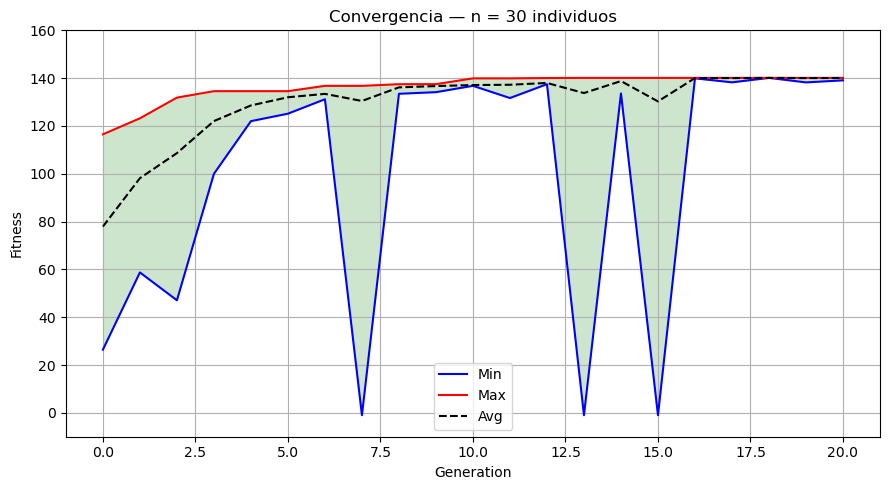


  Población: n = 50
gen	nevals	avg    	std    	min    	max    
0  	50    	79.5138	24.5664	26.4289	122.059
1  	28    	97.8301	18.6489	48.4558	130.873
2  	28    	115.187	13.6357	83.2838	140.132
3  	40    	124.553	19.4919	-1     	136.574
4  	27    	133.61 	3.47646	119.014	140.132
5  	37    	135.631	2.05285	130.873	140.132
6  	30    	134.284	19.451 	-1     	140.132
7  	29    	135.773	19.6169	-1     	140.132
8  	34    	137.125	19.7385	-1     	140.132
9  	30    	140.118	0.191669	138.887	140.677
10 	28    	140.138	0.309691	138.232	140.677
11 	30    	140.176	0.147685	140.132	140.677
12 	27    	140.263	0.232492	140.132	140.677
13 	32    	137.339	19.7939 	-1     	140.677
14 	29    	140.545	0.26766 	139.41 	140.677
15 	28    	140.668	0.0591235	140.254	140.677
16 	29    	137.843	19.8347  	-1     	140.677
17 	31    	140.561	0.810355 	134.888	140.677
18 	28    	140.514	0.830834 	135.436	140.677
19 	34    	140.677	0        	140.677	140.677
20 	25    	137.843	19.8347  	-1     	140.677


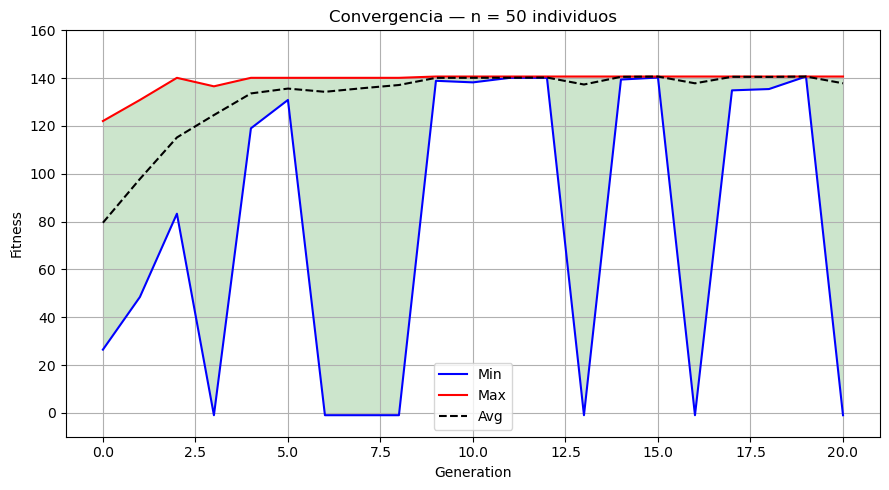

In [8]:
N_GENERACIONES = 20
 
print("\n" + "="*55)
print("  Población: n = 10")
print("="*55)
hof_10, log_10 = ejecutar_ag(10, N_GENERACIONES)
plot_evolucion(log_10, "Convergencia — n = 10 individuos")
 
print("\n" + "="*55)
print("  Población: n = 30")
print("="*55)
hof_30, log_30 = ejecutar_ag(30, N_GENERACIONES)
plot_evolucion(log_30, "Convergencia — n = 30 individuos")
 
print("\n" + "="*55)
print("  Población: n = 50")
print("="*55)
hof_50, log_50 = ejecutar_ag(50, N_GENERACIONES)
plot_evolucion(log_50, "Convergencia — n = 50 individuos")


In [9]:
def ultima_gen(log):
    return log[-1]
 
r10 = ultima_gen(log_10)
r30 = ultima_gen(log_30)
r50 = ultima_gen(log_50)
 
print("\n" + "="*65)
print(f"{'Métrica':<20} {'n = 10':>13} {'n = 30':>13} {'n = 50':>13}")
print("-"*65)
print(f"{'Mejor fitness':<20} {hof_10[0].fitness.values[0]:>13.4f} "
      f"{hof_30[0].fitness.values[0]:>13.4f} {hof_50[0].fitness.values[0]:>13.4f}")
print(f"{'Mejor individuo x':<20} {hof_10[0][0]:>13.4f} "
      f"{hof_30[0][0]:>13.4f} {hof_50[0][0]:>13.4f}")
print(f"{'Mejor individuo y':<20} {hof_10[0][1]:>13.4f} "
      f"{hof_30[0][1]:>13.4f} {hof_50[0][1]:>13.4f}")
print(f"{'Avg última gen':<20} {r10['avg']:>13.4f} "
      f"{r30['avg']:>13.4f} {r50['avg']:>13.4f}")
print(f"{'Std última gen':<20} {r10['std']:>13.4f} "
      f"{r30['std']:>13.4f} {r50['std']:>13.4f}")
print(f"{'Min última gen':<20} {r10['min']:>13.4f} "
      f"{r30['min']:>13.4f} {r50['min']:>13.4f}")
print(f"{'Max última gen':<20} {r10['max']:>13.4f} "
      f"{r30['max']:>13.4f} {r50['max']:>13.4f}")
print("="*65)
print(f"\nValor óptimo real: f(±100, ±100) = {math.sqrt(100**2 + 100**2):.4f}")



Métrica                     n = 10        n = 30        n = 50
-----------------------------------------------------------------
Mejor fitness             136.7789      140.1008      140.6766
Mejor individuo x         -94.6928      -99.3464       99.4752
Mejor individuo y         -98.7002      -98.7853      -99.4716
Avg última gen            136.7789      140.0666      137.8431
Std última gen              0.0000        0.1840       19.8347
Min última gen            136.7789      139.0760       -1.0000
Max última gen            136.7789      140.1008      140.6766

Valor óptimo real: f(±100, ±100) = 141.4214


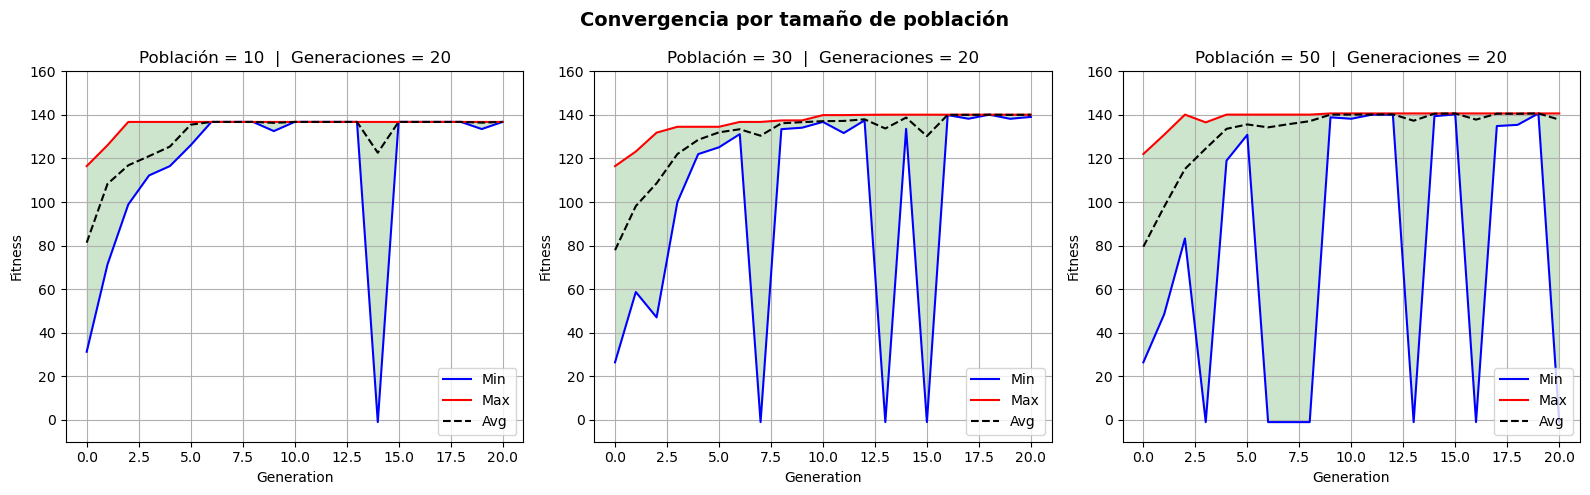

In [10]:
# ------------------------------------------------------------
# Gráfica comparativa: las tres poblaciones en una figura
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Convergencia por tamaño de población", fontweight="bold", fontsize=14)

datos = [
    (log_10, 10),
    (log_30, 30),
    (log_50, 50),
]

for ax, (log, n) in zip(axes, datos):
    gen      = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave  = np.array(log.select("avg"), dtype=float)

    ax.plot(gen, fit_mins, "b",   label="Min")
    ax.plot(gen, fit_maxs, "r",   label="Max")
    ax.plot(gen, fit_ave,  "--k", label="Avg")
    ax.fill_between(gen, fit_mins, fit_maxs,
                    where=fit_maxs >= fit_mins,
                    facecolor="g", alpha=0.2)
    ax.set_title(f"Población = {n}  |  Generaciones = {N_GENERACIONES}")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.set_ylim([-10, 160])
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.savefig("convergencia_comparativa.png", dpi=150)
plt.show()